### Lab 6: Multiple Linear Regression

#### Step-by-Step Instructions:


In [1]:
# Hello everyone, In this lab, we'll walk through a logistic regression example using synthetic disease data.
# We'll use pandas for data manipulation, matplotlib and seaborn for plotting,
# and sklearn for machine learning tasks including model training, evaluation, and metrics.

from sklearn.model_selection import train_test_split  # Importing train_test_split from sklearn for splitting the data
from sklearn.linear_model import LogisticRegression  # Importing LogisticRegression from sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix  # Importing evaluation metrics from sklearn
import matplotlib.pyplot as plt  # Importing matplotlib for plotting
import pandas as pd  # Importing pandas for data manipulation
import seaborn as sns  # Importing seaborn for advanced visualizations
import warnings  # Importing warnings to manage warning messages

# We'll ignore any warnings to keep our output clean.
warnings.filterwarnings('ignore')  # This will suppress any warning messages

# Let's start by loading our dataset into a pandas DataFrame.
data = pd.read_csv('disease_synthetic.csv')  # Reading the CSV file into a DataFrame

# Displaying the first 5 rows of the dataset to get an idea of what it looks like.
print(data.head())  # Displaying the first 5 rows of the DataFrame

# Separating the independent variables (features) and dependent variable (target).
X = data[['Age', 'BMI', 'Exercise_Frequency']]  # Selecting multiple columns as independent variables
y = data['Disease_Outcome']  # Selecting 'Disease_Outcome' as the dependent variable



   Unnamed: 0        Age        BMI  Exercise_Frequency  Disease_Outcome
0           0  70.000000  17.775299            8.443270                1
1           1  51.002358  18.947285            3.154652                1
2           2  59.681070  21.056654            5.995813                1
3           3  70.000000  30.473192            4.301809                1
4           4  70.000000  26.174108            9.090928                1


In [2]:
# Splitting the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)  # Splitting the data with 70% for training and 30% for testing

# Creating a Logistic Regression model and fitting it to the training data.
model = LogisticRegression()  # Creating an instance of LogisticRegression
model.fit(X_train, y_train)  # Fitting the model to the training data

# Using the model to predict Disease Outcome on the test data.
y_pred = model.predict(X_test)  # Making predictions on the test data


Recall Score: 0.8709677419354839


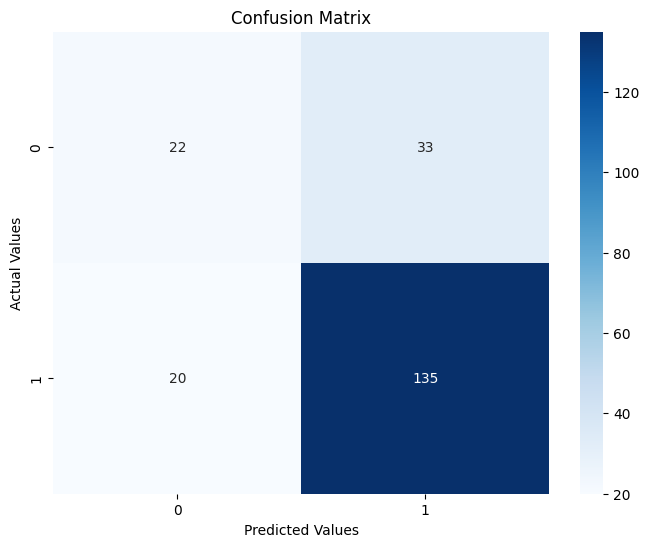

In [3]:

# Calculating and printing the recall score of the model's predictions.
conf_matrix = confusion_matrix(y_test, y_pred)  # Calculating the confusion matrix
print("Recall Score:", recall_score(y_test, y_pred))  # Printing the recall score

# Plotting the confusion matrix as a heatmap.
plt.figure(figsize=(8, 6))  # Creating a new figure with a specified size (8 inches by 6 inches)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues')  # Creating a heatmap with the confusion matrix
plt.title('Confusion Matrix')  # Adding a title to the heatmap
plt.ylabel('Actual Values')  # Labeling the y-axis
plt.xlabel('Predicted Values')  # Labeling the x-axis
plt.show()  # Displaying the heatmap


## For this and the past 2 ML problems that we solved, Let's revise the flow we took to create an ML project. 

Flow Explanation:
Import Libraries:

We begin by importing necessary libraries including pandas for data manipulation, matplotlib and seaborn for plotting, and sklearn for machine learning tasks.
We also import warnings to suppress any unwanted warnings.
Load and Inspect Data:

We load the synthetic disease data into a DataFrame using pandas.
We inspect the first few rows of the data to understand its structure and contents.
Prepare Data:

We separate the independent variables (features) and the dependent variable (target) from the dataset.
Independent variables include Age, BMI, and Exercise_Frequency.
The dependent variable is Disease_Outcome.
Split Data:

We split the data into training and testing sets using train_test_split.
Here, 70% of the data is used for training the model, and 30% is used for testing.
Train Model:

We create an instance of the LogisticRegression model.
We fit the model to the training data using the fit method.
Make Predictions:

We use the trained model to make predictions on the test data using the predict method.
Evaluate Model:

We evaluate the model's performance by calculating the confusion matrix and recall score.
The confusion matrix provides a summary of prediction results, while the recall score gives an idea of how well the model identifies positive instances.
Visualize Results:

We visualize the confusion matrix using a heatmap for better understanding and interpretation.
The heatmap displays the actual vs. predicted values, helping us see where the model is performing well and where it may be making mistakes.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, recall_score, accuracy_score

In [7]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

In [13]:
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled.iloc[:, 1:] = scaler.fit_transform(X.iloc[:, 1:]) 
X_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,1,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,8,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584
3,1,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549
4,0,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496


In [16]:
#70% training, 30% Testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (537, 8)
Testing set size: (231, 8)


In [18]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model Coefficients:", model.coef_)

Model Coefficients: [[ 0.13829661  1.14709477 -0.20562795 -0.04037438 -0.08006758  0.71873321
   0.2321063   0.09289745]]


In [19]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[0 0 1 1 0 0 1 0 0 0]


In [20]:
conf_matrix = confusion_matrix(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print(f"Recall Score: {recall}")
print(f"Accuracy Score: {accuracy}")

Confusion Matrix:
 [[130  20]
 [ 39  42]]
Recall Score: 0.5185185185185185
Accuracy Score: 0.7445887445887446


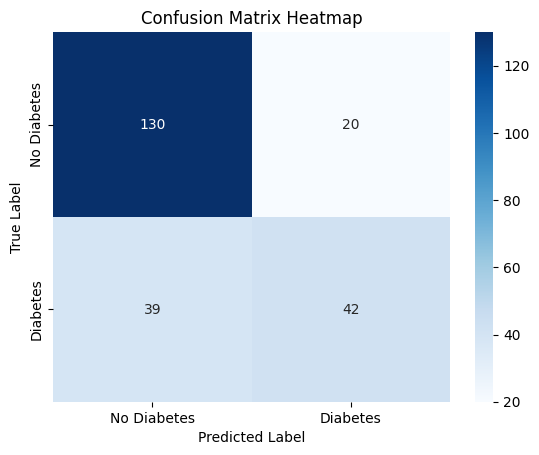

In [21]:
sns.heatmap(conf_matrix, annot=True, fmt='d',cmap="Blues", 
            xticklabels=["No Diabetes", "Diabetes"], 
            yticklabels=["No Diabetes", "Diabetes"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()